# Phase 1: Data Understanding and Cleaning

## Objectives

In this phase, you will:

1. Load and understand the structure of the House Prices dataset
2. Identify and handle duplicate entries
3. Analyze data types and categorize features
4. Identify and handle missing values
5. Detect and handle outliers
6. Create a clean baseline dataset for further processing

## Instructions

Follow each task sequentially. Document your observations and decisions in markdown cells.

---
## Task 1: Import Libraries

Import the necessary libraries for data cleaning.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import os
print(pd.__version__)
# Set working directory to project root
os.chdir('/home/admin123/Desktop/ML-DS-DL-AI/Kaggle-Competition/House-Prices')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

3.0.1
Libraries imported successfully!


---
## Task 2: Load the Dataset

Load the training dataset and display basic information.

**Questions to answer:**
- How many observations (rows) are in the dataset?
- How many features (columns) are available?
- What is the target variable we want to predict?

In [77]:
# TODO: Load the training data from 'train.csv' using pd.read_csv()
# Store it in a variable called 'df'
df = pd.read_csv("data/train/train.csv")
# TODO: Print the following information:
# - Success message
print("Data loaded successfully!")
# - Dataset shape (hint: use df.shape)
print("Dataset shape:", df.shape)
# - Number of observations (hint: df.shape[0] gives rows)
print("Number of observations:", df.shape[0])
# - Number of features (hint: df.shape[1] gives columns)
print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (1460, 81)
Number of observations: 1460
Number of features: 81


In [78]:
# TODO: Display the first 5 rows of the dataset
# Use the .head() method on the dataframe
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [79]:
# TODO: Display dataset information using .info() method
# This shows: data types, non-null counts, and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Your Observations:

Write your observations here:
- Total rows: 1460
- Total columns: 81
- Target variable: SalePrice
- Notable features: Street, Neighborhood, LotArea, KitchenQual, GarageArea, SaleCondition

---
## Task 3: Check for Duplicate Rows

Identify if there are any duplicate observations in the dataset.

In [80]:
# TODO: Check for duplicate rows in the dataset
# - Use df.duplicated() to find duplicates
# - Use .sum() to count them
# - Print message and the count
print(df.duplicated())
print(f"Number of duplicated rows: {df.duplicated().sum()}")
# TODO: If duplicates exist (count > 0), display them
# - Use df[df.duplicated(keep=False)] to show all duplicate rows
# - keep=False marks all duplicates as True (not just first/last occurrence)

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Length: 1460, dtype: bool
Number of duplicated rows: 0


**Action Required:**

If duplicates exist, decide whether to:
- Remove them (if they are exact duplicates)
- Investigate further (if they might be legitimate similar properties)

Document your decision and implement it below.

In [81]:
# Your code here to handle duplicates if needed

---
## Task 4: Identify Feature Types

Categorize features into numerical and categorical types.

**Note:** Some numerical features might actually represent categories (e.g., MSSubClass). Use the data description file to identify these.

In [82]:
# TODO: Create lists of categorical and numerical columns
# - Use list comprehension to filter columns by dtype
# - Categorical: df[col].dtype == 'object'
# - Numerical: df[col].dtype != 'object'
cat_cols = [col for col in df.columns if df[col].dtype == 'object' or df[col].dtype == 'string']
num_cols = [col for col in df.columns if df[col].dtype != 'object' and df[col].dtype != 'string']
# TODO: Print the following:
# - Number of categorical columns
print(f"Number of categorical columns: {len(cat_cols)}")
# - Number of numerical columns
print(f"Number of numerical columns: {len(num_cols)}")
# - List of categorical column names
print(f"Categorical columns: {cat_cols}")
# - List of numerical column names
print(f"Numerical columns: {num_cols}")

Number of categorical columns: 43
Number of numerical columns: 38
Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr

In [83]:
# TODO: Analyze unique values in each categorical column
# - Use .nunique() to count unique values per column
# - Use .sort_values(ascending=False) to show highest cardinality first
print("Unique values for each column: \n", df[cat_cols].nunique().sort_values(ascending=False))
# Hint: df[cat_col].nunique().sort_values(ascending=False)

Unique values for each column: 
 Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64


In [84]:
df[num_cols].nunique().sort_values()

HalfBath            3
BsmtHalfBath        3
BsmtFullBath        4
FullBath            4
Fireplaces          4
KitchenAbvGr        4
GarageCars          5
YrSold              5
PoolArea            8
BedroomAbvGr        8
OverallCond         9
OverallQual        10
TotRmsAbvGrd       12
MoSold             12
MSSubClass         15
3SsnPorch          20
MiscVal            21
LowQualFinSF       24
YearRemodAdd       61
ScreenPorch        76
GarageYrBlt        97
LotFrontage       110
YearBuilt         112
EnclosedPorch     120
BsmtFinSF2        144
OpenPorchSF       202
WoodDeckSF        274
MasVnrArea        327
2ndFlrSF          417
GarageArea        441
BsmtFinSF1        637
SalePrice         663
TotalBsmtSF       721
1stFlrSF          753
BsmtUnfSF         780
GrLivArea         861
LotArea          1073
Id               1460
dtype: int64

**Question:** 

Looking at the data description file and the unique values, identify any numerical columns that should be treated as categorical. List them here and explain why.

Numerical columns that should be treated as categorical: OverallQual, OverallCond, MSSubClass

Description is given for each number, so these columns can be treated as categorical.

---
## Task 5: Analyze Missing Values

Identify which features have missing values and calculate the percentage of missing data.

In [85]:
# TODO: Calculate missing values for each column
# - Use df.isnull().sum() to count missing values
# - Calculate percentage: (missing_count / total_rows) * 100
# - Round to 2 decimal places
mis_values = df.isnull().sum()
mis_percent = round((mis_values / df.shape[0]) * 100, 2)
# TODO: Create a DataFrame with columns: 'Column', 'Missing_Count', 'Missing_Percentage'
df_2 = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": mis_values,
    "Missing_Percentage": mis_percent
})
# TODO: Filter to show only columns with missing values (Missing_Count > 0)
# - Sort by Missing_Percentage in descending order
# - Reset the index
df_2 = df_2[df_2["Missing_Count"] > 0].sort_values(by="Missing_Percentage", ascending=False).reset_index(drop=True)
# TODO: Print summary
# - Number of features with missing values
# - The missing values summary DataFrame
print(f"Number of features with missing values: {df_2.shape[0]}")
print(df_2)

Number of features with missing values: 19
          Column  Missing_Count  Missing_Percentage
0         PoolQC           1453               99.52
1    MiscFeature           1406               96.30
2          Alley           1369               93.77
3          Fence           1179               80.75
4     MasVnrType            872               59.73
5    FireplaceQu            690               47.26
6    LotFrontage            259               17.74
7     GarageType             81                5.55
8    GarageYrBlt             81                5.55
9   GarageFinish             81                5.55
10    GarageQual             81                5.55
11    GarageCond             81                5.55
12  BsmtExposure             38                2.60
13  BsmtFinType2             38                2.60
14      BsmtQual             37                2.53
15      BsmtCond             37                2.53
16  BsmtFinType1             37                2.53
17    MasVnrArea     

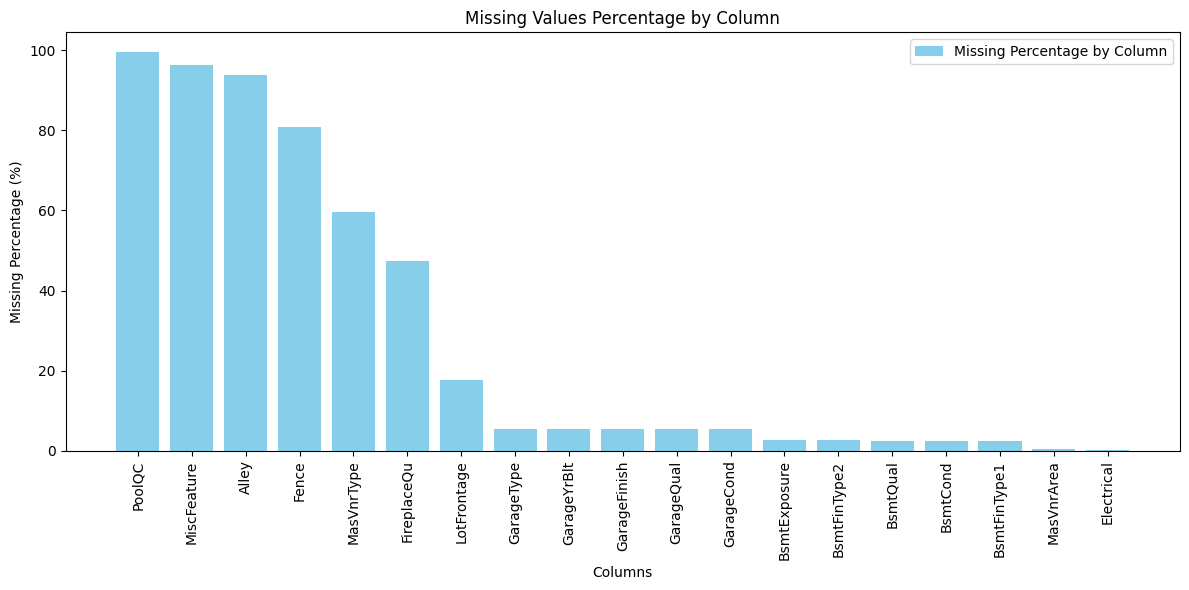

In [86]:
# TODO: Create a bar plot to visualize missing values
# - Create figure with size (12, 6)
# - Use plt.bar() with Column names and Missing_Percentage
# - Rotate x-axis labels 90 degrees for readability
# - Add labels: xlabel, ylabel, title
# - Add horizontal line at 50% threshold (use plt.axhline)
# - Add legend and use plt.tight_layout()
# - Display with plt.show()
plt.figure(figsize=(12,6))
plt.bar(df_2["Column"], df_2["Missing_Percentage"],color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.title("Missing Values Percentage by Column")
plt.tight_layout()
plt.legend(["Missing Percentage by Column"])
plt.show()

---
## Task 6: Handle Missing Values

Develop a strategy for handling missing values. Consider:

1. **High missing rate (>50%):** Consider dropping the feature
2. **Moderate missing rate (15-50%):** Impute or flag
3. **Low missing rate (<15%):** Impute based on feature type
4. **Missing by design:** Some features might be missing because the property doesn't have that feature (e.g., no pool, no garage). Check data_description.txt

**Strategy Guidelines:**
- For categorical: Use mode or create 'None'/'Missing' category
- For numerical: Use mean, median, or predictive imputation
- Consider the feature's importance (read data_description.txt)

### Step 6.1: Identify Features to Drop

List features with very high missing rates that provide little value.

In [87]:
# TODO: Create a list of features to drop
# - Consider features with >50% missing values
# - Consider features with low importance (check data_description.txt)
# Example: features_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# Initialize empty list
features_to_drop = ["BsmtExposure"]  # Add feature names based on your analysis

features_to_drop = features_to_drop + (df_2.loc[df_2['Missing_Percentage'] > 50, 'Column']).tolist()
# TODO: Document reasoning for each dropped feature
# Loop through features_to_drop and print why each is being removed

As the result of checking data_description.txt, these 4 features don't have much effect: 

1.GarageYrBlt - If the garage's current condition is not known, its built year don't tell anything to us.

2.BsmtExposure - In my opinion, this feature doesn't give much info about house price.

### Step 6.2: Handle Categorical Missing Values

For categorical features with missing values, decide on imputation strategy.

In [88]:
# TODO: Create a working copy of the dataframe
df_clean = df.copy()

# TODO: Drop selected features (if any in your features_to_drop list)
# - Use df.drop(columns=features_to_drop) if list is not empty
# - Print how many features were dropped
df_clean.drop(columns=features_to_drop,inplace=True)
print("The number of dropped features: ",df.shape[1] - df_clean.shape[1])
# TODO: Handle categorical missing values
# Strategy 1: Fill with 'None' for features where missing means absence
mis_abs = ['GarageType', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtCond', 'BsmtQual','BsmtFinType1','BsmtFinType2']
df_clean[mis_abs] = df_clean[mis_abs].fillna('Missing')
# Strategy 2: Fill with mode for features where missing is random
mis_rand = ['Electrical']
imputer = SimpleImputer(strategy='most_frequent')
df_clean[mis_rand] = imputer.fit_transform(df_clean[mis_rand])
# Refer to data_description.txt to decide which strategy for each feature

The number of dropped features:  6


In [89]:
miss_val_col = (df_2.loc[~df_2['Column'].isin(features_to_drop),'Column'].tolist())
df[miss_val_col].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FireplaceQu   770 non-null    str    
 1   LotFrontage   1201 non-null   float64
 2   GarageType    1379 non-null   str    
 3   GarageYrBlt   1379 non-null   float64
 4   GarageFinish  1379 non-null   str    
 5   GarageQual    1379 non-null   str    
 6   GarageCond    1379 non-null   str    
 7   BsmtFinType2  1422 non-null   str    
 8   BsmtQual      1423 non-null   str    
 9   BsmtCond      1423 non-null   str    
 10  BsmtFinType1  1423 non-null   str    
 11  MasVnrArea    1452 non-null   float64
 12  Electrical    1459 non-null   str    
dtypes: float64(3), str(10)
memory usage: 148.4 KB


### Step 6.3: Handle Numerical Missing Values

For numerical features with missing values, choose appropriate imputation.

In [90]:
# TODO: Handle numerical missing values
# Choose appropriate strategy based on the feature:
df['MasVnrArea'].value_counts()
# Option 1: Fill with median (robust to outliers)
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['GarageYrBlt'].median())
# Option 2: Fill with mean (if data is normally distributed)
#   Example: df_clean['FeatureName'].fillna(df_clean['FeatureName'].mean(), inplace=True)
#
# Option 3: Fill with 0 (if missing means absence of that feature)
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

# Analyze each numerical feature with missing values and apply appropriate strategy

In [91]:
# TODO: Verify all missing values are handled
# - Calculate total remaining missing values: df_clean.isnull().sum().sum()
# - Print the count
# - If any remain, print which features still have missing values
df_clean.isnull().sum().sum()


np.int64(0)

---
## Task 7: Detect and Analyze Outliers

Use box plots and IQR method to identify outliers in key numerical features.

In [92]:
# TODO: Select key numerical features for outlier analysis
# Focus on features related to size, area, and price
# Example list: ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'SalePrice']
key_numeric_features = ['LotArea', 'MasVnrArea', 'BsmtUnfSF', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
'3SsnPorch', 'ScreenPorch', 'PoolArea', 'GarageCars','LotFrontage','BsmtFinSF1','BsmtFinSF2','1stFlrSF', '2ndFlrSF','LowQualFinSF','SalePrice']
# TODO: Filter to only those that exist in df_clean
key_numeric_features = [col for col in key_numeric_features if col in df_clean.columns]

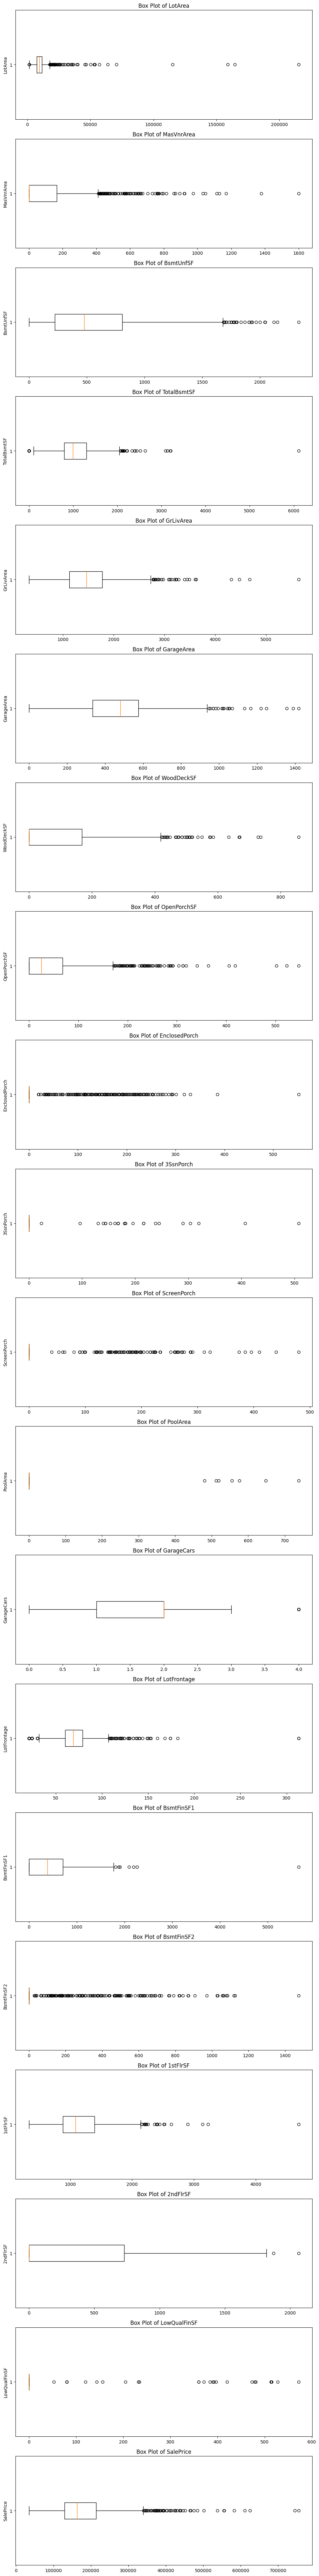

In [93]:
# TODO: Create box plots for each key numerical feature
fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(10, 4*len(key_numeric_features)))
# - Handle case when only 1 feature: convert axes to list
# - Loop through features and create horizontal box plot for each
#   - Use axes[i].boxplot(df_clean[col].dropna(), vert=False)
#   - Set ylabel and title
# - Use plt.tight_layout() and plt.show()
if len(key_numeric_features) == 1:
    axes = [axes]
for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

### Step 7.1: Calculate Outliers Using IQR Method

For selected features, identify outliers using the IQR method.

In [94]:
# TODO: Create a function to detect outliers using IQR method
# Function should:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile) using np.percentile()
# 2. Calculate IQR = Q3 - Q1
# 3. Calculate bounds: lower_bound = Q1 - 1.5 * IQR, upper_bound = Q3 + 1.5 * IQR
# 4. Find outliers: values < lower_bound OR values > upper_bound
# 5. Return: outliers dataframe, lower_bound, upper_bound

# TODO: Apply function to each key numerical feature
# - Loop through key_numeric_features
# - Print column name, bounds, and number of outliers found

def IQR_finding_outliers(df,column):
    Q1 = np.percentile(df[column].dropna(),25)
    Q3 = np.percentile(df[column].dropna(),75)
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound ,upper_bound

for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers found: {outliers.shape[0]}\n")


Column: LotArea
Lower Bound: 1481.5, Upper Bound: 17673.5
Number of outliers found: 69

Column: MasVnrArea
Lower Bound: -246.375, Upper Bound: 410.625
Number of outliers found: 98

Column: BsmtUnfSF
Lower Bound: -654.5, Upper Bound: 1685.5
Number of outliers found: 29

Column: TotalBsmtSF
Lower Bound: 42.0, Upper Bound: 2052.0
Number of outliers found: 61

Column: GrLivArea
Lower Bound: 158.625, Upper Bound: 2747.625
Number of outliers found: 31

Column: GarageArea
Lower Bound: -27.75, Upper Bound: 938.25
Number of outliers found: 21

Column: WoodDeckSF
Lower Bound: -252.0, Upper Bound: 420.0
Number of outliers found: 32

Column: OpenPorchSF
Lower Bound: -102.0, Upper Bound: 170.0
Number of outliers found: 77

Column: EnclosedPorch
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers found: 208

Column: 3SsnPorch
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers found: 24

Column: ScreenPorch
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers found: 116

Column: PoolArea
Lower 

### Step 7.2: Decision on Outliers

**Important:** Not all outliers should be removed. Consider:
- Are they data entry errors or legitimate extreme values?
- Do they represent rare but valid properties (e.g., mansions, unique homes)?
- Will removing them improve or harm model performance?

Document your decision for handling outliers.

In [95]:
# Examine extreme outliers in detail
# Example: Look at properties with very large living area
# extreme_area = df_clean[df_clean['GrLivArea'] > 4000]
# print(extreme_area[['GrLivArea', 'SalePrice', 'OverallQual', 'OverallCond']])]
outlier_detected_columns = ["LotArea", "BsmtUnfSF", "TotalBsmtSF", "GrLivArea", "GarageArea", "OpenPorchSF", 
                            "GarageCars", "LotFrontage", "BsmtFinSF1", "BsmtUnfSF", "1stFlrSF"]
# Your analysis here

In [96]:
# TODO: Decide whether to remove specific outliers
# Important: Not all outliers should be removed!
# 
# Consider:
# - Are they data entry errors or legitimate extreme values?
# - Do they represent rare but valid properties (mansions, unique homes)?
# 
# If removing outliers, document your reasoning
# Example: df_clean = df_clean[df_clean['GrLivArea'] < 4000]
for col in outlier_detected_columns:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


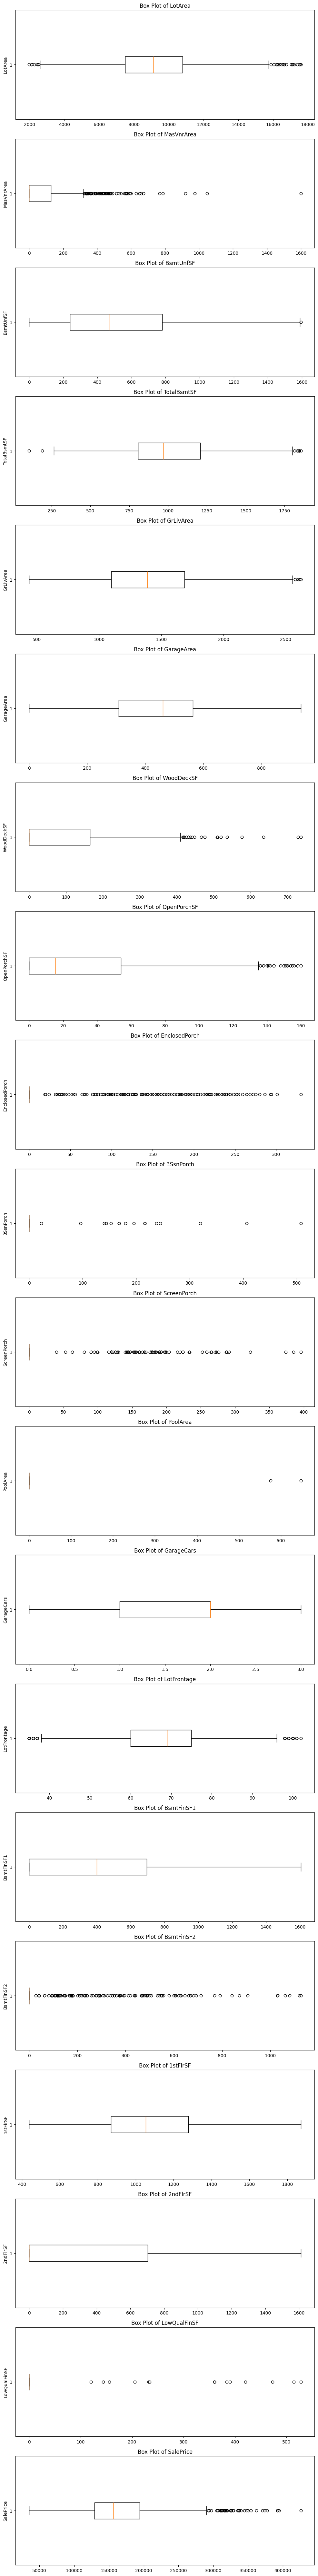

In [97]:
#CHECKING OUTLIERS AFTER CLEANING

fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(10, 4*len(key_numeric_features)))
if len(key_numeric_features) == 1:
    axes = [axes]
for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

---
## Task 8: Final Data Verification

Verify the cleaned dataset is ready for the next phase.

In [98]:
# TODO: Print final dataset summary
# Compare original vs cleaned:
# - Original shape vs cleaned shape
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
# - Number of rows removed
print(f"Number of rows removed: {df.shape[0] - df_clean.shape[0]}")
# - Number of columns removed
print(f"Number of columns removed: {df.shape[1] - df_clean.shape[1]}")
# - Remaining missing values count
print(f"Remaining missing values count: {df_clean.isnull().sum().sum()}")
# - Data types value counts
print("Data types value counts:")
print(df_clean.dtypes.value_counts())

Original dataset shape: (1460, 81)
Cleaned dataset shape: (1086, 75)
Number of rows removed: 374
Number of columns removed: 6
Remaining missing values count: 0
Data types value counts:
str        37
int64      35
float64     3
Name: count, dtype: int64


In [99]:
print(df_clean.shape[0] / df.shape[0] * 100)

74.38356164383562


In [100]:
# TODO: Save the cleaned dataset to CSV
df_clean.to_csv('train_cleaned.csv', index=False)
# - Print confirmation message
print("Cleaned dataset saved to 'train_cleaned.csv'")

Cleaned dataset saved to 'train_cleaned.csv'


---
## Summary and Reflection

### What You Accomplished:

1. Loaded and understood the House Prices dataset structure
2. Identified and handled duplicate entries
3. Categorized features into numerical and categorical types
4. Analyzed and handled missing values systematically
5. Detected and addressed outliers using IQR method
6. Created a clean baseline dataset

### Key Questions for Reflection:

1. What percentage of the original data was retained after cleaning? 
2. Which features had the most missing data and how did you handle them?
3. Did you identify any patterns in the missing data?
4. How did you decide which outliers to keep vs. remove?
5. What challenges did you encounter and how did you address them?

### Next Steps:

Proceed to **Phase 2: Data Preprocessing** where you will:
- Encode categorical variables
- Scale numerical features
- Handle skewness
- Prepare the data for feature engineering